In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow
import keras

In [3]:
from keras.layers import Dense
from keras import Sequential

In [35]:
(X_train,y_train),(X_test,y_test) = keras.datasets.mnist.load_data()

In [38]:
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

In [39]:
X_train = X_train.astype('float32') / 255.
X_test = X_test.astype('float32') / 255.

In [40]:
X_train.shape

(60000, 28, 28)

## we have 60K rows of Data, Each Data Point is of 28*28 size, which mean, each row is a 2D point

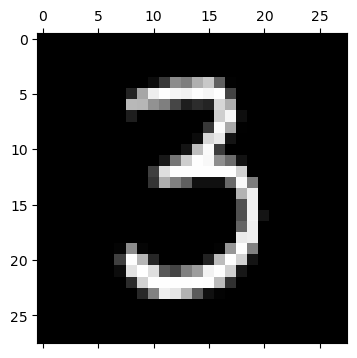

In [41]:
plt.rcParams['figure.figsize']= [4,4]
plt.matshow(X_train[50])

In [42]:
X_train.shape

(60000, 28, 28)

### let's convert the image into 1D array

In [43]:
X_train = X_train.reshape(len(X_train), np.prod(X_train.shape[1:]))

In [44]:
X_test = X_test.reshape(len(X_test), np.prod(X_test.shape[1:]))

In [45]:
X_test.shape

(10000, 784)

# AutoEncoder

In [46]:
from keras.layers import Dense, Input
from keras import Model

In [54]:
input_img = keras.Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [55]:
model = Model(inputs=input_img, outputs = decoded)

In [56]:
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy'
)

In [62]:
model.fit(X_train, X_train, epochs=50, batch_size=128, shuffle=True, validation_data=(X_test, X_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0038 - val_loss: 0.0039
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━

In [63]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

In [64]:
decoded_images = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


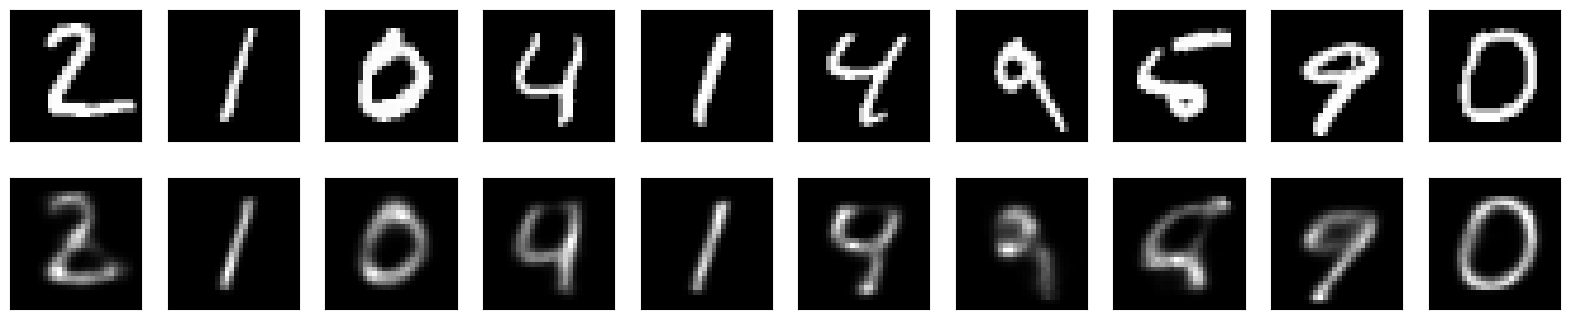

In [65]:
n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_images[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [66]:
img_inp = Input(shape=(784,))
encoded = Dense(128, activation='relu')(img_inp)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)
encoded = Dense(8, activation='relu')(encoded)
encoded = Dense(4, activation='relu')(encoded)
encoded = Dense(2, activation='relu')(encoded)

decoded = Dense(4, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(decoded)
decoded = Dense(16, activation='relu')(decoded)
decoded = Dense(32, activation='relu')(decoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [67]:
model2 = Model(inputs=img_inp, outputs=decoded)

In [73]:
model2.compile(
    optimizer = keras.optimizers.Adam(),
    loss = keras.losses.BinaryCrossentropy
)

In [74]:
model2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,834 (874.35 KB)

 Trainable params: 223,834 (874.35 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model2.fit(X_train, X_train, epochs = 50, batch_size=256, shuffle=True, validation_data = (X_test, X_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - loss: 0.1411 - val_loss: 0.0041
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━

In [78]:
predicted = model2.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


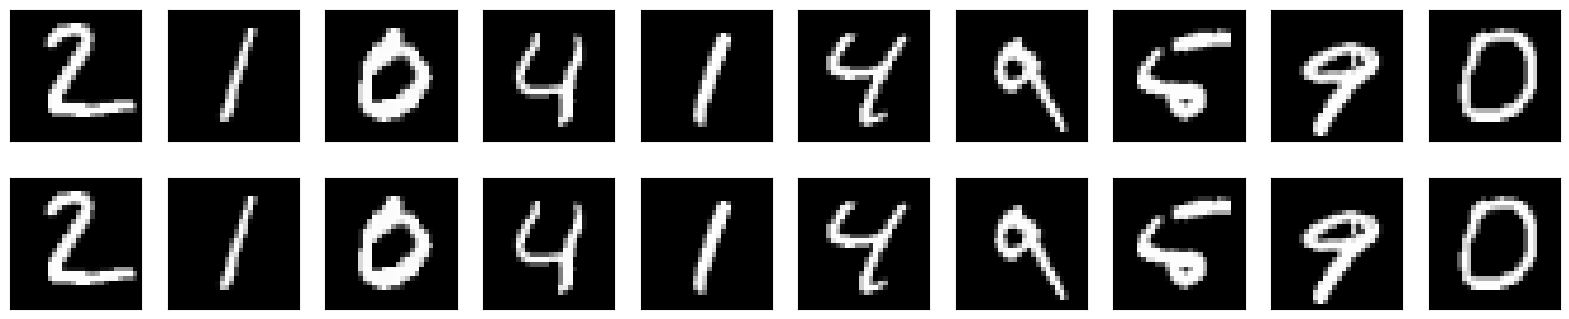

In [81]:
n = 10
plt.figure(figsize=(20,4))

for i in range(1,n+1):
    ax=plt.subplot(2,n,i)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2,n,i+n)
    plt.imshow(X_test[i].reshape(28,28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

In [85]:
dim_model2 = Model(model2.input,model2.layers[7].output)

In [89]:
from keras.datasets import mnist

In [90]:
(x_train, _), (x_test, _) = mnist.load_data()

#Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

#Reshape
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

#add NOISE - adding noise with random normal distribution
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print(x_train.shape)
print(x_train_noisy.shape)
print(x_test.shape)
print(x_test_noisy.shape)

(60000, 784)
(60000, 784)
(10000, 784)
(10000, 784)


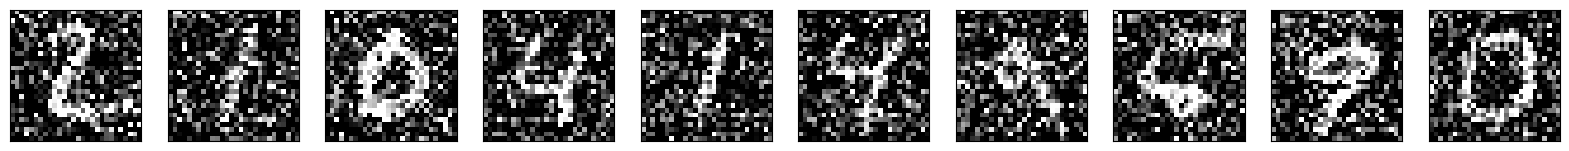

In [91]:
n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [93]:
input_img = keras.Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

# Compile and Fit
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_noisy, x_train, # NOTE: input is noisy, output is non-noisy
                epochs=100,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.2613 - val_loss: 0.1928
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1780 - val_loss: 0.1657
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.1605 - val_loss: 0.1543
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1521 - val_loss: 0.1479
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1466 - val_loss: 0.1432
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1423 - val_loss: 0.1394
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1389 - val_loss: 0.1364
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1363 - val_loss: 0.1344
Epoch 9/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1341 - val_loss: 0.1328
Epoch 10/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1322 - val_loss: 0.1311
Epoch 11/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1305 - val_loss: 0.1293
Epoch 12/100
235/235 ━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


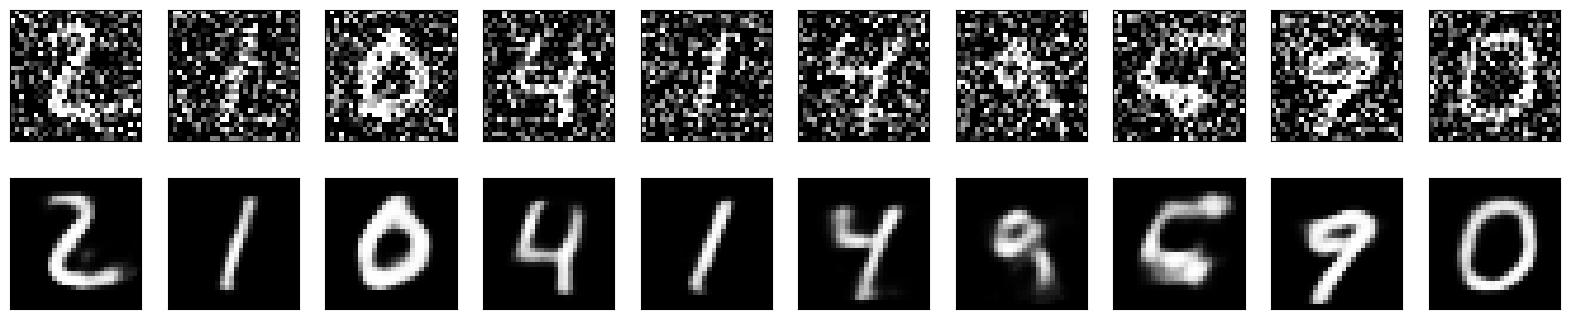

In [94]:
#Visualize the outputs
import matplotlib.pyplot as plt

decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    # Display original
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()